# Exploración de `movies` y `ratings`

## 1. Introducción

Este notebook cruza el catálogo de películas (`movies.csv`) con las calificaciones que reciben
(`ratings.csv`) para responder la misma pregunta general de siempre en este tipo de análisis:
**¿qué se ve y qué se califica bien?**, separando dos aspectos:

* **cuánto** se califica una película (popularidad);
* **qué tan alto** se califica (calidad percibida).

**Aviso importante sobre el origen de los datos:** `ratings.csv` completo tiene **32 000 205
calificaciones** y no es manejable directamente en este entorno. Este notebook trabaja sobre
`ratings_sample.csv`, una **muestra aleatoria sistemática de 500 000 filas** (≈1.56 % del total),
generada tomando 1 de cada 32 filas del archivo original ya ordenado por `userId`. Esto es
importante porque:

* Todo lo que se calcula **solo con `movies.csv`** (título, año, género) es **exacto**: es la tabla
  completa, no una muestra.
* Todo lo que involucra **calificaciones** (popularidad, calificación media, distribución de
  ratings) es una **estimación** basada en la muestra, no el valor exacto del dataset completo.
  Con 500 000 observaciones aleatorias la estimación es razonablemente precisa para patrones
  generales, pero dos cosas se ven directamente afectadas: (1) películas con muy pocas
  calificaciones reales pueden no aparecer del todo en la muestra, y (2) el número de
  calificaciones que trae la muestra para cada película **no es** su número real de calificaciones
  en el dataset completo, solo una versión a escala reducida.

## 2. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## 3. Carga de datos

In [2]:
RUTA_MOVIES = "../../Datasets/ml-32m/movies.csv"
RUTA_RATINGS_MUESTRA = "../../Datasets/ml-32m/ratings_sample.csv"

movies = pd.read_csv(RUTA_MOVIES)
ratings = pd.read_csv(RUTA_RATINGS_MUESTRA)
ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s")

print(f"movies:  {movies.shape[0]} filas, {movies.shape[1]} columnas (catálogo completo)")
print(f"ratings: {ratings.shape[0]} filas, {ratings.shape[1]} columnas (muestra del dataset de "
      f"32 000 205 calificaciones reales)")

movies:  87585 filas, 3 columnas (catálogo completo)
ratings: 500000 filas, 5 columnas (muestra del dataset de 32 000 205 calificaciones reales)


## 4. Exploración inicial

### 4.1 `movies`

In [3]:
movies.info()
print()
movies.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  87585 non-null  int64
 1   title    87585 non-null  str  
 2   genres   87585 non-null  str  
dtypes: int64(1), str(2)
memory usage: 2.0 MB



,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [4]:
print(f"Nulos por columna:\n{movies.isnull().sum()}\n")
print(f"movieId duplicados: {movies['movieId'].duplicated().sum()}")
print(f"title duplicados (mismo texto, distinto movieId): {movies['title'].duplicated().sum()}")

# Inspección de un caso de título duplicado, para entender si es un error o películas distintas
ejemplo = movies[movies["title"] == "Aladdin (1992)"]
print("\nEjemplo — dos películas distintas con el mismo título:")
ejemplo

Nulos por columna:
movieId    0
title      0
genres     0
dtype: int64

movieId duplicados: 0
title duplicados (mismo texto, distinto movieId): 203

Ejemplo — dos películas distintas con el mismo título:


,movieId,title,genres
580,588,Aladdin (1992),Adventure|Animation|Children|Comedy|Musical
22298,114240,Aladdin (1992),Adventure|Animation|Children|Comedy|Fantasy


**Resultados:** sin valores nulos y sin `movieId` duplicado (la clave es única, como debe ser). Sí
hay **203 títulos que se repiten** con `movieId` distinto — el ejemplo de "Aladdin (1992)" muestra que
son entradas separadas del catálogo (una animada de Disney, otra con géneros distintos), no errores de
carga: probablemente remakes, adaptaciones o duplicados legítimos del catálogo colaborativo de
MovieLens. **Conclusión:** no se deben deduplicar por título — `movieId` es la clave correcta y ya es
única.

### 4.2 `ratings` (muestra)

In [5]:
ratings.info()
print()
ratings.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype        
---  ------     --------------   -----        
 0   userId     500000 non-null  int64        
 1   movieId    500000 non-null  int64        
 2   rating     500000 non-null  float64      
 3   timestamp  500000 non-null  int64        
 4   datetime   500000 non-null  datetime64[s]
dtypes: datetime64[s](1), float64(1), int64(3)
memory usage: 19.1 MB



,userId,movieId,rating,timestamp,datetime
0,1,1784,1.0,943228545,1999-11-21 23:55:45
1,2,216,4.0,836424027,1996-07-03 20:00:27
2,2,362,5.0,836424125,1996-07-03 20:02:05
3,2,466,3.0,836424079,1996-07-03 20:01:19
4,3,168,3.5,1084484387,2004-05-13 21:39:47
5,3,2268,4.0,1084484382,2004-05-13 21:39:42
6,5,165,4.0,840764017,1996-08-23 01:33:37
7,5,208,3.0,840768639,1996-08-23 02:50:39
8,5,364,5.0,840768897,1996-08-23 02:54:57
9,6,2167,5.0,1100059947,2004-11-10 04:12:27


In [6]:
print(f"Nulos por columna:\n{ratings.isnull().sum()}\n")
print(f"Pares (userId, movieId) duplicados: {ratings.duplicated(subset=['userId', 'movieId']).sum()}")
print(f"Usuarios distintos en la muestra: {ratings['userId'].nunique():,} "
      f"(el dataset completo tiene 200 948 usuarios registrados)")
print(f"Películas distintas calificadas en la muestra: {ratings['movieId'].nunique():,} "
      f"de las {movies.shape[0]:,} del catálogo")
print(f"Valores posibles de rating: {sorted(ratings['rating'].unique())}")
print(f"Rango temporal de las calificaciones: {ratings['datetime'].min().date()} — "
      f"{ratings['datetime'].max().date()}")

Nulos por columna:
userId       0
movieId      0
rating       0
timestamp    0
datetime     0
dtype: int64

Pares (userId, movieId) duplicados: 0
Usuarios distintos en la muestra: 135,185 (el dataset completo tiene 200 948 usuarios registrados)
Películas distintas calificadas en la muestra: 21,279 de las 87,585 del catálogo
Valores posibles de rating: [np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]
Rango temporal de las calificaciones: 1996-01-29 — 2023-10-13


**Resultados:** sin nulos, sin pares usuario-película duplicados. La muestra cubre 135 185 de los
200 948 usuarios reales (67 %) y 21 279 de las 87 585 películas del catálogo (24 %) — es esperable que
no aparezcan todas las películas, ya que muchas tienen muy pocas calificaciones en total y la
probabilidad de que ninguna caiga en una muestra del 1.56 % es alta. Las calificaciones van de 0.5 a
5.0 en pasos de 0.5 estrella (a diferencia del dataset ml-100k usado en otro trabajo del curso, que
solo admitía enteros de 1 a 5). El rango temporal cubre desde 1996 hasta 2023, todo el histórico del
dataset completo — la muestra no está sesgada hacia ningún periodo.

## 5. Transformaciones

**Qué se hace:** se extrae el año de estreno del título (formato `"Título (AAAA)"`), se identifican
las películas sin año reconocible, y se separan los géneros (columna `genres`, con formato
`"Género1|Género2|..."`) en indicadores binarios por género para poder analizarlos por separado.

**Por qué es necesaria:** el año está mezclado con el texto del título y no se puede usar tal cual; los
géneros no son mutuamente excluyentes (una película puede tener varios), así que no sirven como una
sola columna categórica.

In [7]:
movies["year"] = movies["title"].str.extract(r"\((\d{4})\)\s*$").astype("float")
sin_anio = movies["year"].isna().sum()
print(f"Películas sin año reconocible en el título: {sin_anio} de {len(movies)} "
      f"({sin_anio / len(movies) * 100:.2f}%)")
movies.loc[movies["year"].isna(), "title"].head(5)

Películas sin año reconocible en el título: 617 de 87585 (0.70%)


15038              Millions Game, The (Das Millionenspiel)
18796    Mona and the Time of Burning Love (Mona ja pal...
25425                                   Terrible Joe Moran
26356                 The Court-Martial of Jackie Robinson
26381                                        In Our Garden
Name: title, dtype: str

In [8]:
movies["sin_genero"] = movies["genres"] == "(no genres listed)"
print(f"Películas marcadas como '(no genres listed)': {movies['sin_genero'].sum()} "
      f"({movies['sin_genero'].mean() * 100:.1f}%) — se tratan como categoría propia, no se excluyen.")

# Un indicador binario por género (excluye la marca de "sin género" para no contarla como género)
generos_texto = movies.loc[~movies["sin_genero"], "genres"]
generos_dummies = generos_texto.str.get_dummies("|")
GENEROS = generos_dummies.columns.tolist()
print(f"\nGéneros identificados ({len(GENEROS)}): {GENEROS}")
print("\nNota: 'IMAX' aparece en la columna de géneros de MovieLens, pero es un formato de "
      "proyección, no un género narrativo; se incluye en las pruebas por transparencia, pero su "
      "resultado debe leerse con esa salvedad.")

Películas marcadas como '(no genres listed)': 7080 (8.1%) — se tratan como categoría propia, no se excluyen.



Géneros identificados (19): ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

Nota: 'IMAX' aparece en la columna de géneros de MovieLens, pero es un formato de proyección, no un género narrativo; se incluye en las pruebas por transparencia, pero su resultado debe leerse con esa salvedad.


## 6. Unidad de observación

* En **`movies`**, cada fila representa **una película** del catálogo (`movieId` es la clave única).
* En **`ratings`**, cada fila representa **una calificación**: un evento en el que un usuario
  (`userId`) le puso una nota a una película (`movieId`) en un momento (`timestamp`). Un mismo usuario
  aparece tantas veces como películas haya calificado.

## 7. Cruce con `movies` y validación del merge

In [9]:
huerfanas = ~ratings["movieId"].isin(movies["movieId"])
print(f"Calificaciones cuya película no existe en movies.csv: {huerfanas.sum()}")

df = ratings.merge(movies, on="movieId", how="inner")
print(f"Filas antes del merge: {ratings.shape[0]} | después: {df.shape[0]} "
      f"| ¿se conservan todas?: {df.shape[0] == ratings.shape[0]}")
print(f"Pares (userId, movieId) duplicados tras el merge: "
      f"{df.duplicated(subset=['userId', 'movieId']).sum()}")
df.head(3)

Calificaciones cuya película no existe en movies.csv: 0
Filas antes del merge: 500000 | después: 500000 | ¿se conservan todas?: True
Pares (userId, movieId) duplicados tras el merge: 0


,userId,movieId,rating,timestamp,datetime,title,genres,year,sin_genero
0,1,1784,1.0,943228545,1999-11-21 23:55:45,As Good as It Gets (1997),Comedy|Drama|Romance,1997.0,False
1,2,216,4.0,836424027,1996-07-03 20:00:27,Billy Madison (1995),Comedy,1995.0,False
2,2,362,5.0,836424125,1996-07-03 20:02:05,"Jungle Book, The (1994)",Adventure|Children|Romance,1994.0,False


**Resultados:** cero calificaciones huérfanas y cero filas perdidas o duplicadas en el merge — el
catálogo de películas cubre completamente los `movieId` que aparecen en la muestra de calificaciones.

**Conclusión:** el cruce es correcto y no requiere ningún ajuste adicional.

## 8. Nota metodológica: unidad de análisis

In [10]:
perfil = (
    df.groupby("movieId")
    .agg(
        title=("title", "first"),
        year=("year", "first"),
        genres=("genres", "first"),
        sin_genero=("sin_genero", "first"),
        n_calificaciones=("rating", "size"),
        calificacion_media=("rating", "mean"),
    )
    .reset_index()
)
generos_perfil = perfil.loc[~perfil["sin_genero"], "genres"].str.get_dummies("|")
perfil = perfil.join(generos_perfil)

# Diccionario donde se guardan los p-valores para corregirlos al final (sección 10)
pruebas = {}

print(f"Perfil de películas (en la muestra): {perfil.shape[0]} filas, una por película")
perfil[["title", "year", "n_calificaciones", "calificacion_media"]].head()

Perfil de películas (en la muestra): 21279 filas, una por película


,title,year,n_calificaciones,calificacion_media
0,Toy Story (1995),1995.0,1015,3.894089
1,Jumanji (1995),1995.0,439,3.308656
2,Grumpier Old Men (1995),1995.0,211,3.078199
3,Waiting to Exhale (1995),1995.0,38,2.907895
4,Father of the Bride Part II (1995),1995.0,206,3.087379


La tabla cruzada tiene 500 000 filas pero solo 21 279 películas distintas. Igual que en los
notebooks de `user` e `item` de compañeros del curso anterior, las calificaciones de una misma
película no son independientes entre sí, así que:

* **Descripción a nivel de calificación** (n = 500 000): para la distribución general de los valores
  de rating, que es una propiedad del acto de calificar, no de la película.
* **Inferencia a nivel de película** (n = 21 279, o el subconjunto que corresponda tras filtrar por un
  mínimo de calificaciones): para cualquier comparación entre películas o géneros, agregando primero
  cada película a su calificación media y su número de calificaciones.

A esto se suma la advertencia de la introducción: como el n por película viene de una muestra, para
las comparaciones "mejor/peor calificada" se exige un **mínimo de calificaciones dentro de la muestra**
(no en el dataset completo) para evitar que una película con 1-2 calificaciones muy altas o muy bajas
en la muestra parezca una tendencia real.

### Funciones auxiliares

In [11]:
def cliffs_delta(a, b):
    """Tamaño del efecto no paramétrico. |d| < 0.147 despreciable, < 0.33 pequeño, < 0.474 mediano."""
    u, _ = stats.mannwhitneyu(a, b, alternative="two-sided")
    return 2 * u / (len(a) * len(b)) - 1


def holm(p_valores):
    """Corrección de Holm-Bonferroni para comparaciones múltiples."""
    ordenados = sorted(p_valores.items(), key=lambda par: par[1])
    m = len(ordenados)
    ajustados, maximo_previo = {}, 0.0
    for i, (nombre, p) in enumerate(ordenados):
        maximo_previo = max(maximo_previo, min(1.0, (m - i) * p))
        ajustados[nombre] = maximo_previo
    return ajustados

## 9. Exploración descriptiva

### 9.1 Distribución general de las calificaciones (nivel calificación, n = 500 000)

In [12]:
print(ratings["rating"].describe().round(3), "\n")
moda = ratings["rating"].mode().iloc[0]
enteras = (ratings["rating"] % 1 == 0).mean()
print(f"Moda: {moda} | Asimetría: {ratings['rating'].skew():.3f}")
print(f"Proporción de calificaciones en número entero (1, 2, 3, 4 o 5): {enteras * 100:.1f}%"
      f" — el resto son medias estrellas.")

count    500000.000
mean          3.539
std           1.060
min           0.500
25%           3.000
50%           3.500
75%           4.000
max           5.000
Name: rating, dtype: float64 

Moda: 4.0 | Asimetría: -0.718
Proporción de calificaciones en número entero (1, 2, 3, 4 o 5): 68.9% — el resto son medias estrellas.


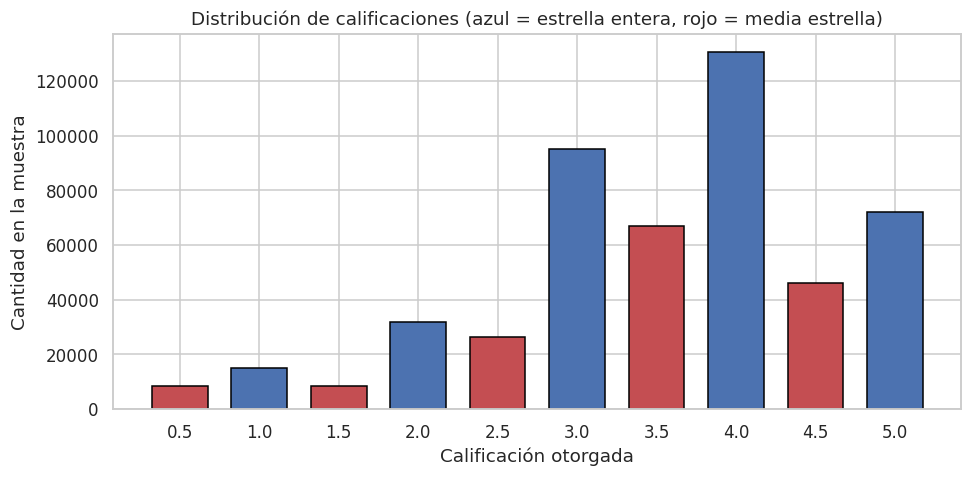

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
conteo = ratings["rating"].value_counts().sort_index()
colores = ["#C44E52" if v % 1 != 0 else "#4C72B0" for v in conteo.index]
ax.bar(conteo.index.astype(str), conteo.values, color=colores, edgecolor="black", width=0.7)
ax.set_xlabel("Calificación otorgada")
ax.set_ylabel("Cantidad en la muestra")
ax.set_title("Distribución de calificaciones (azul = estrella entera, rojo = media estrella)")
fig.tight_layout()
plt.show()

**Resultados:** media 3.54, mediana 3.5, moda 4.0, con asimetría negativa leve (la gente tiende a
calificar más alto que bajo). El 68.9 % de las calificaciones son en número entero, aunque solo 5 de
los 10 valores posibles (1, 2, 3, 4, 5) son enteros — si la gente usara la escala de 0.5 en 0.5 sin
ninguna preferencia, ese porcentaje debería rondar el 50 %.

**Conclusión:** hay una preferencia clara por las estrellas enteras sobre las medias estrellas, un
patrón conocido en escalas de este tipo (anclaje a los números "redondos"). Esto no es un error de los
datos, es un patrón de comportamiento del usuario que conviene tener presente si se construye
cualquier modelo sobre esta variable.

### 9.2 Popularidad por película (nivel película)

In [14]:
popularidad = perfil["n_calificaciones"]
print(popularidad.describe().round(2), "\n")
print(f"Asimetría: {popularidad.skew():.2f}")

n_top = int(round(len(perfil) * 0.10))
top_populares = popularidad.sort_values(ascending=False).head(n_top)
print(f"\nEl 10% más popular en la muestra ({n_top} películas) concentra el "
      f"{top_populares.sum() / popularidad.sum() * 100:.1f}% de las calificaciones de la muestra")

count    21279.00
mean        23.50
std         78.19
min          1.00
25%          1.00
50%          2.00
75%         11.00
max       1581.00
Name: n_calificaciones, dtype: float64 

Asimetría: 7.97

El 10% más popular en la muestra (2128 películas) concentra el 76.6% de las calificaciones de la muestra


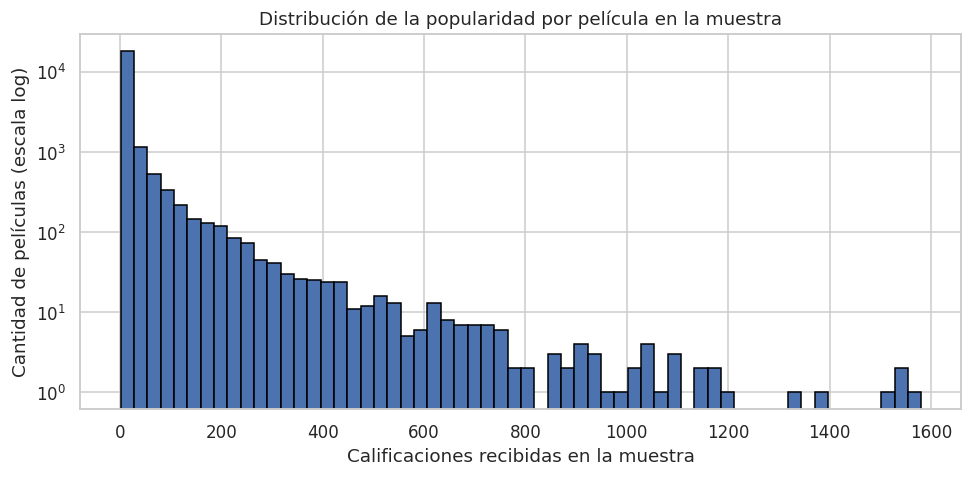

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(popularidad, bins=60, color="#4C72B0", edgecolor="black")
ax.set_yscale("log")
ax.set_xlabel("Calificaciones recibidas en la muestra")
ax.set_ylabel("Cantidad de películas (escala log)")
ax.set_title("Distribución de la popularidad por película en la muestra")
fig.tight_layout()
plt.show()

**Resultados:** mediana de solo 2 calificaciones por película en la muestra frente a una media de
23.5 (asimetría 7.97, muy superior a la del ejemplo con ml-100k). El 10 % más popular concentra el
76.6 % de las calificaciones de la muestra.

**Conclusión:** la concentración es todavía más extrema que en un catálogo pequeño como ml-100k, algo
esperable: con 87 585 películas y calificaciones limitadas, la inmensa mayoría del catálogo son títulos
de nicho vistos por muy pocas personas, mientras un puñado de éxitos domina el volumen. Es la
justificación empírica de por qué las comparaciones de la sección 9.4 exigen un mínimo de
calificaciones en la muestra.

### 9.3 Distribución de géneros (nivel película — exacta, viene del catálogo completo)

In [16]:
conteo_generos = movies.loc[~movies["sin_genero"], "genres"].str.get_dummies("|").sum().sort_values(ascending=False)
print(conteo_generos)

Drama          34175
Comedy         23124
Thriller       11823
Romance        10369
Action          9668
Documentary     9363
Horror          8654
Crime           6976
Adventure       5402
Sci-Fi          4907
Animation       4617
Children        4520
Mystery         4013
Fantasy         3851
War             2325
Western         1696
Musical         1059
Film-Noir        353
IMAX             195
dtype: int64


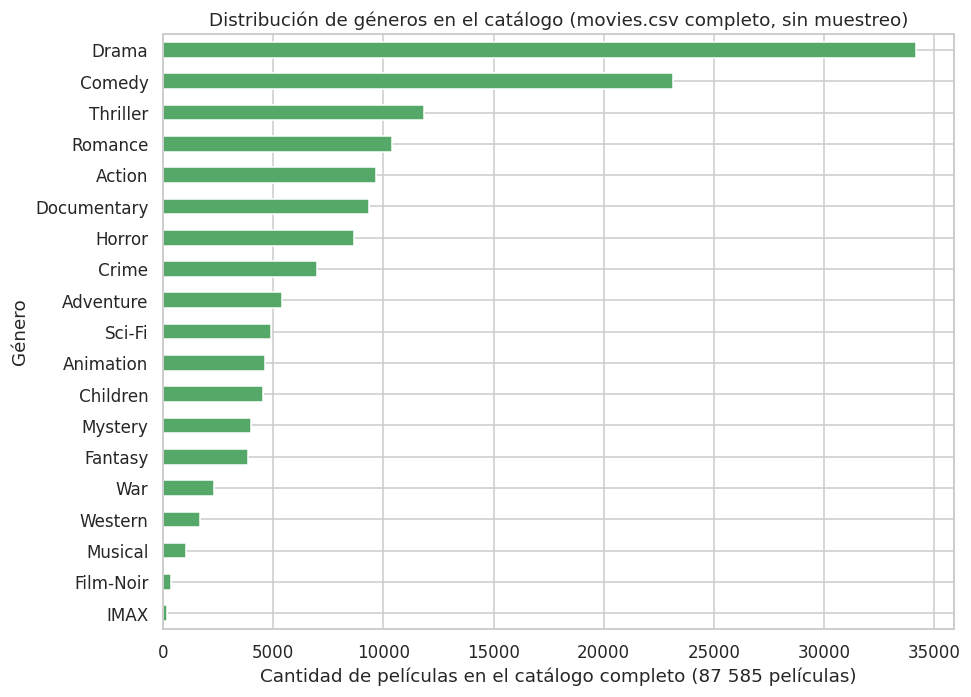

In [17]:
fig, ax = plt.subplots(figsize=(9, 6.5))
conteo_generos.sort_values().plot(kind="barh", color="#55A868", ax=ax)
ax.set_xlabel("Cantidad de películas en el catálogo completo (87 585 películas)")
ax.set_ylabel("Género")
ax.set_title("Distribución de géneros en el catálogo (movies.csv completo, sin muestreo)")
fig.tight_layout()
plt.show()

**Resultados:** Drama (34 175 películas) y Comedy (23 124) dominan claramente el catálogo; en el
otro extremo, Film-Noir (353) e IMAX (195, aunque no es un género narrativo) son los más escasos. A
diferencia de las secciones anteriores, **esta cifra es exacta**, no una estimación por muestreo,
porque se calcula sobre `movies.csv` completo.

**Conclusión:** el catálogo de MovieLens está fuertemente inclinado hacia Drama y Comedy — cualquier
comparación de calificación por género (sección 10) debe leerse sabiendo que esos dos géneros pesan
muchísimo más que el resto en número de películas disponibles.

### 9.4 Distribución temporal

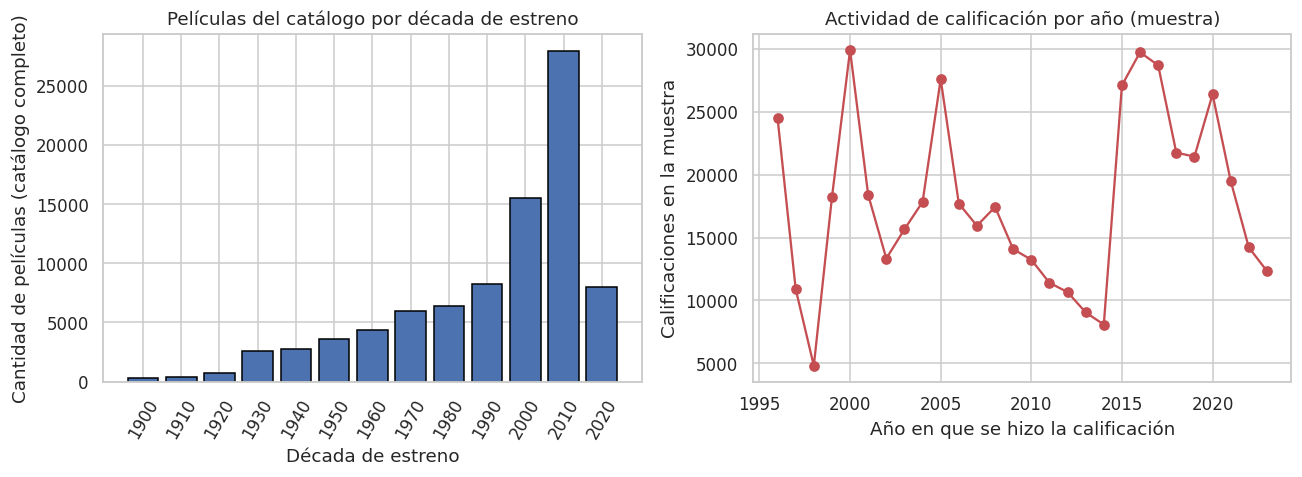

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

por_decada = (movies["year"].dropna() // 10 * 10).astype(int).value_counts().sort_index()
por_decada = por_decada[por_decada.index >= 1900]
ax1.bar(por_decada.index.astype(str), por_decada.values, color="#4C72B0", edgecolor="black")
ax1.set_xlabel("Década de estreno")
ax1.set_ylabel("Cantidad de películas (catálogo completo)")
ax1.set_title("Películas del catálogo por década de estreno")
ax1.tick_params(axis="x", rotation=60)

por_anio_calif = ratings["datetime"].dt.year.value_counts().sort_index()
ax2.plot(por_anio_calif.index, por_anio_calif.values, marker="o", color="#C44E52")
ax2.set_xlabel("Año en que se hizo la calificación")
ax2.set_ylabel("Calificaciones en la muestra")
ax2.set_title("Actividad de calificación por año (muestra)")

fig.tight_layout()
plt.show()

**Resultados:** el catálogo crece de forma sostenida década tras década (más películas recientes que
antiguas, como es de esperar en cualquier catálogo acumulativo). La actividad de calificación por año
(en la muestra) es muy desigual: hay picos y valles marcados, coherentes con los distintos momentos en
que MovieLens ha importado lotes de datos o ha tenido campañas de usuarios nuevos, más que con un
patrón estacional suave.

**Conclusión:** ninguna de las dos series es plana — el catálogo no ha dejado de crecer y la
intensidad de uso de la plataforma ha variado bastante entre años, lo cual es contexto útil antes de
interpretar cualquier tendencia "a través del tiempo" en las siguientes secciones.

## 10. Relaciones entre variables

### 10.1 Popularidad y calidad: ¿lo más visto es lo mejor calificado?

**Qué se calcula:** correlación de **Spearman** entre el número de calificaciones de una película en
la muestra y su calificación media.

**Hipótesis:** H₀: ρ = 0.

In [19]:
rho_pop, p_pop = stats.spearmanr(perfil["n_calificaciones"], perfil["calificacion_media"])
pruebas["Spearman popularidad ~ calificación media"] = p_pop
print(f"Spearman popularidad ~ calificación media: rho = {rho_pop:.3f} | p = {p_pop:.2e}")

Spearman popularidad ~ calificación media: rho = 0.113 | p = 1.85e-61


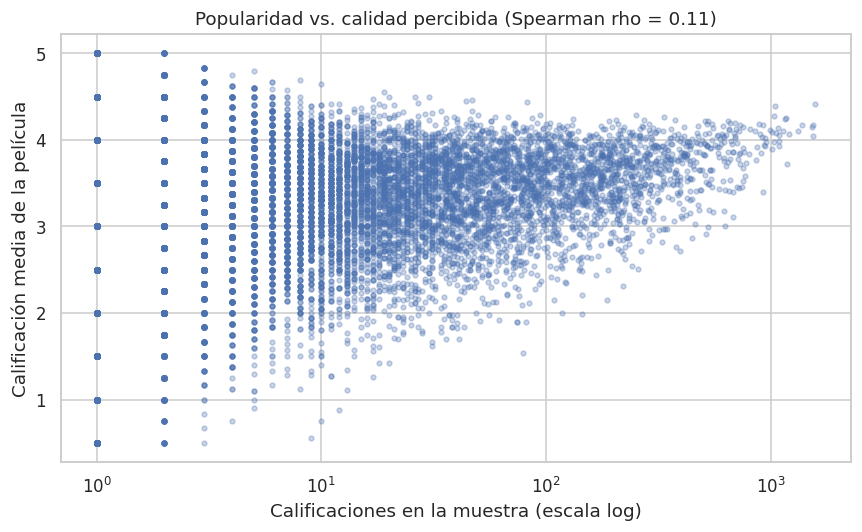

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(perfil["n_calificaciones"], perfil["calificacion_media"], s=10, alpha=0.3, color="#4C72B0")
ax.set_xscale("log")
ax.set_xlabel("Calificaciones en la muestra (escala log)")
ax.set_ylabel("Calificación media de la película")
ax.set_title(f"Popularidad vs. calidad percibida (Spearman rho = {rho_pop:.2f})")
fig.tight_layout()
plt.show()

**Resultados:** **ρ = 0.113** (p < 0.001) — estadísticamente significativo por el tamaño de la
muestra, pero un efecto **débil**.

**Conclusión:** a esta escala de catálogo (87 585 películas, la mayoría de nicho), ser más popular
apenas se asocia con estar mejor calificado. Es una diferencia notable frente al catálogo pequeño y
curado de ml-100k (donde esa misma correlación había dado ρ = 0.50): con un catálogo mucho más amplio y
heterogéneo, la popularidad y la calidad se desacoplan bastante más. No se puede tratar "más vista"
como sinónimo de "mejor calificada" en este dataset.

### 10.2 Año de estreno y calificación

**Qué se calcula:** correlación de Spearman entre el año de estreno y la calificación media, entre
las películas con al menos 5 calificaciones en la muestra (para que la calificación media no sea el
promedio de 1-2 votos).

**Hipótesis:** H₀: ρ = 0.

In [21]:
perfil_con_year = perfil.dropna(subset=["year"])
perfil_confiable = perfil_con_year[perfil_con_year["n_calificaciones"] >= 5]
print(f"Películas con año conocido y al menos 5 calificaciones en la muestra: {len(perfil_confiable)}")

rho_year, p_year = stats.spearmanr(perfil_confiable["year"], perfil_confiable["calificacion_media"])
pruebas["Spearman año de estreno ~ calificación media"] = p_year
print(f"Spearman año de estreno ~ calificación media: rho = {rho_year:.3f} | p = {p_year:.2e}")

Películas con año conocido y al menos 5 calificaciones en la muestra: 8091
Spearman año de estreno ~ calificación media: rho = -0.107 | p = 5.51e-22


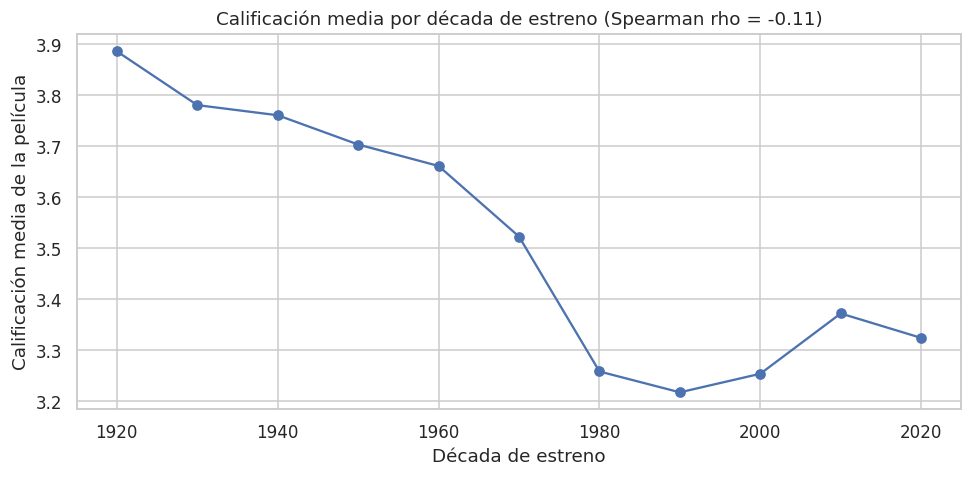

In [22]:
fig, ax = plt.subplots(figsize=(9, 4.5))
por_decada_rating = (
    perfil_confiable.assign(decada=(perfil_confiable["year"] // 10 * 10).astype(int))
    .groupby("decada")["calificacion_media"].agg(["mean", "size"])
)
por_decada_rating = por_decada_rating[por_decada_rating["size"] >= 10]
ax.plot(por_decada_rating.index, por_decada_rating["mean"], marker="o", color="#4C72B0")
ax.set_xlabel("Década de estreno")
ax.set_ylabel("Calificación media de la película")
ax.set_title(f"Calificación media por década de estreno (Spearman rho = {rho_year:.2f})")
fig.tight_layout()
plt.show()

**Resultados:** **ρ = -0.107** (p < 0.001), negativo y también débil: las películas más antiguas
tienden a calificarse ligeramente mejor.

**Conclusión:** el mismo patrón cualitativo que en ml-100k (sesgo de supervivencia: las películas viejas
que siguen circulando y siendo calificadas tienden a ser las que se sostuvieron por ser buenas), pero
con un tamaño de efecto todavía más pequeño en este catálogo mucho más amplio y con siete décadas
adicionales de estrenos recientes que diluyen la relación.

### 10.3 Calificación por género

**Qué se calcula:** para cada género, se compara con **Mann-Whitney** la calificación media de las
películas de ese género contra las que no lo son, con tamaño del efecto (delta de Cliff). Igual que en
`data_item.ipynb` del trabajo anterior, se hace género por género porque no son mutuamente excluyentes.
Se exige un mínimo de 5 películas con ese género en la muestra para que la prueba tenga sentido.

In [23]:
filas_genero = []
for genero in GENEROS:
    en = perfil.loc[perfil[genero] == 1, "calificacion_media"]
    fuera = perfil.loc[perfil[genero] == 0, "calificacion_media"]
    if len(en) < 5:
        continue
    _, p = stats.mannwhitneyu(en, fuera, alternative="two-sided")
    delta = cliffs_delta(en, fuera)
    pruebas[f"MW calificación media ~ género {genero}"] = p
    filas_genero.append((genero, len(en), en.mean(), fuera.mean(), p, delta))

tabla_generos = pd.DataFrame(
    filas_genero, columns=["género", "n_películas", "media_en_género", "media_fuera", "p", "delta_cliff"]
).sort_values("p").reset_index(drop=True)
tabla_generos.round(4)

,género,n_películas,media_en_género,media_fuera,p,delta_cliff
0,Drama,9605,3.3331,3.0763,0.0000,0.1821
1,Horror,2351,2.8186,3.2424,0.0000,-0.2864
2,Documentary,1447,3.4954,3.1722,0.0000,0.2556
3,Action,3194,3.0510,3.2206,0.0000,-0.1386
4,Sci-Fi,1733,2.9896,3.2132,0.0000,-0.1640
5,Thriller,3848,3.1049,3.2149,0.0000,-0.0934
6,Comedy,6802,3.1378,3.2221,0.0000,-0.0771
7,Children,1267,2.9939,3.2076,0.0000,-0.1433
8,War,790,3.3850,3.1871,0.0000,0.1605
9,Film-Noir,179,3.5341,3.1917,0.0000,0.2774


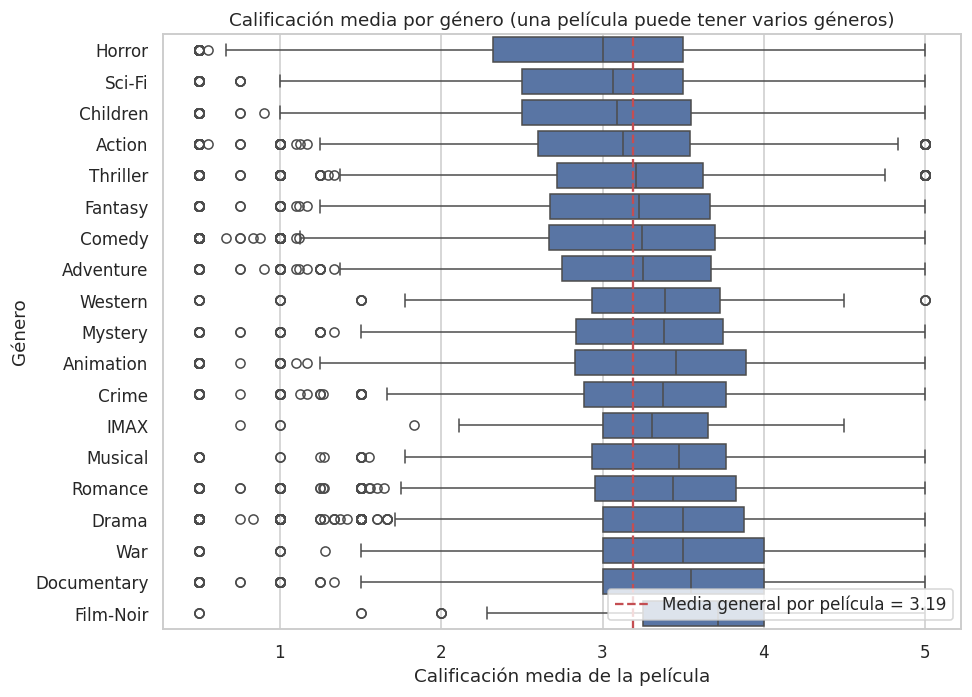

In [24]:
orden = tabla_generos.sort_values("media_en_género")["género"]
generos_melt = perfil.melt(
    id_vars="calificacion_media", value_vars=GENEROS, var_name="género", value_name="pertenece"
).query("pertenece == 1")

fig, ax = plt.subplots(figsize=(9, 6.5))
sns.boxplot(data=generos_melt, y="género", x="calificacion_media", order=orden, color="#4C72B0", ax=ax)
ax.axvline(perfil["calificacion_media"].mean(), color="#C44E52", linestyle="--",
           label=f"Media general por película = {perfil['calificacion_media'].mean():.2f}")
ax.set_xlabel("Calificación media de la película")
ax.set_ylabel("Género")
ax.set_title("Calificación media por género (una película puede tener varios géneros)")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

**Resultados (antes de corregir):** Film-Noir (media 3.53, delta = 0.28), Documentary (3.50,
delta = 0.26) y Drama (3.33, delta = 0.18) se califican mejor que el resto; Horror (2.82, delta = -0.29),
Sci-Fi (2.99, delta = -0.16) y Children (2.99, delta = -0.14) se califican peor. Mystery, IMAX y Western
no muestran diferencia apreciable.

**Conclusión:** el patrón general (Drama arriba, Horror abajo) coincide con lo observado en ml-100k,
aunque aquí Documentary y Film-Noir aparecen con una ventaja más marcada — posiblemente porque en un
catálogo de 87 585 películas, quienes buscan y califican documentales o cine negro específicamente
suelen ser espectadores con un interés particular en ese género, más proclives a valorarlo bien.

## 11. Top y bottom: películas más/menos populares y mejor/peor calificadas

**Umbral elegido:** para "mejor/peor calificada" se exige un mínimo de **30 calificaciones en la
muestra** (de las 21 279 películas de la muestra, solo 3 018 lo cumplen). Es un umbral más exigente que
proporcional al de ml-100k porque, al ser una muestra y no el dataset completo, cualquier mínimo bajo
deja pasar películas cuya calificación "verdadera" en el dataset completo podría ser muy distinta.

In [25]:
min_calif = 30
candidatas = perfil[perfil["n_calificaciones"] >= min_calif]
print(f"Películas con al menos {min_calif} calificaciones en la muestra: {len(candidatas)}")

print("\nTop 10 más populares en la muestra:")
display(perfil.nlargest(10, "n_calificaciones")[["title", "n_calificaciones", "calificacion_media"]])

print(f"\nTop 10 mejor calificadas (mínimo {min_calif} calificaciones en la muestra):")
display(candidatas.nlargest(10, "calificacion_media")[["title", "n_calificaciones", "calificacion_media"]])

print(f"\nBottom 10 peor calificadas (mínimo {min_calif} calificaciones en la muestra):")
display(candidatas.nsmallest(10, "calificacion_media")[["title", "n_calificaciones", "calificacion_media"]])

Películas con al menos 30 calificaciones en la muestra: 3018

Top 10 más populares en la muestra:


,title,n_calificaciones,calificacion_media
302,"Shawshank Redemption, The (1994)",1581,4.412081
2284,"Matrix, The (1999)",1548,4.172804
339,Forrest Gump (1994),1542,4.044423
280,Pulp Fiction (1994),1523,4.151346
558,"Silence of the Lambs, The (1991)",1379,4.168600
248,Star Wars: Episode IV - A New Hope (1977),1324,4.097432
4447,"Lord of the Rings: The Fellowship of the Ring,...",1207,4.062138
454,Jurassic Park (1993),1179,3.717981
2636,Fight Club (1999),1165,4.252790
501,Schindler's List (1993),1157,4.240277



Top 10 mejor calificadas (mínimo 30 calificaciones en la muestra):


,title,n_calificaciones,calificacion_media
17063,Planet Earth II (2016),30,4.500000
17023,Band of Brothers (2001),47,4.457447
16254,Planet Earth (2006),44,4.443182
1126,M (1931),82,4.439024
302,"Shawshank Redemption, The (1994)",1581,4.412081
774,"Godfather, The (1972)",1045,4.392344
1688,"Best Years of Our Lives, The (1946)",34,4.338235
12431,Paperman (2012),47,4.329787
6593,High and Low (Tengoku to jigoku) (1963),31,4.306452
3225,"Gold Rush, The (1925)",50,4.290000



Bottom 10 peor calificadas (mínimo 30 calificaciones en la muestra):


,title,n_calificaciones,calificacion_media
3194,Battlefield Earth (2000),79,1.531646
3169,"Flintstones in Viva Rock Vegas, The (2000)",31,1.612903
2913,Stop! Or My Mom Will Shoot (1992),31,1.661290
1249,Jaws 3-D (1983),36,1.694444
1547,Spice World (1997),41,1.695122
63,Lawnmower Man 2: Beyond Cyberspace (1996),34,1.779412
376,Street Fighter (1994),40,1.825000
1489,Mortal Kombat: Annihilation (1997),43,1.837209
5636,Dumb and Dumberer: When Harry Met Lloyd (2003),34,1.838235
1899,"Avengers, The (1998)",38,1.842105


**Resultados:** las más populares en la muestra son títulos ampliamente reconocibles (*The Shawshank
Redemption*, *The Matrix*, *Pulp Fiction*, *Forrest Gump*), lo que da confianza en que el muestreo
sistemático sí está capturando bien los patrones reales de popularidad. Entre las mejor calificadas
(con al menos 30 votos en la muestra) aparecen documentales de naturaleza (*Planet Earth*, *Planet Earth
II*) y clásicos consagrados (*The Godfather*, *The Shawshank Redemption*); entre las peor calificadas,
secuelas de baja recepción crítica (*Battlefield Earth*, *Jaws 3-D*, *Spice World*).

**Conclusión:** estas listas describen la muestra, no garantizan ser exactamente el top/bottom real del
dataset completo — pero el hecho de que las películas más populares de la muestra coincidan con títulos
de reconocimiento cultural masivo es una señal de que el muestreo sistemático no introdujo un sesgo
evidente.

## 12. Corrección por comparaciones múltiples

**Qué se calcula:** el ajuste de **Holm-Bonferroni** sobre los p-valores de las pruebas por género
más las dos correlaciones (popularidad y año de estreno).

In [26]:
ajustados = holm(pruebas)
tabla_pruebas = pd.DataFrame({
    "p_original": pd.Series(pruebas),
    "p_ajustado_holm": pd.Series(ajustados),
})
tabla_pruebas["significativo_5%"] = np.where(tabla_pruebas["p_ajustado_holm"] < 0.05, "sí", "no")
n_sig = (tabla_pruebas["significativo_5%"] == "sí").sum()
print(f"Pruebas significativas al 5% tras el ajuste: {n_sig} de {len(tabla_pruebas)}")
tabla_pruebas.sort_values("p_original").round(5)

Pruebas significativas al 5% tras el ajuste: 16 de 21


,p_original,p_ajustado_holm,significativo_5%
MW calificación media ~ género Drama,0.00000,0.00000,sí
MW calificación media ~ género Horror,0.00000,0.00000,sí
Spearman popularidad ~ calificación media,0.00000,0.00000,sí
MW calificación media ~ género Documentary,0.00000,0.00000,sí
MW calificación media ~ género Action,0.00000,0.00000,sí
MW calificación media ~ género Sci-Fi,0.00000,0.00000,sí
Spearman año de estreno ~ calificación media,0.00000,0.00000,sí
MW calificación media ~ género Thriller,0.00000,0.00000,sí
MW calificación media ~ género Comedy,0.00000,0.00000,sí
MW calificación media ~ género Children,0.00000,0.00000,sí


**Resultados:** 16 de las 21 pruebas siguen siendo significativas al 5 % tras el ajuste. No
sobreviven Musical, Crime, Mystery, IMAX y Western —los cinco géneros que ya tenían p más altos sin
corregir—.

**Conclusión:** los hallazgos robustos de este notebook son el desacople relativamente débil entre
popularidad y calidad (comparado con catálogos pequeños), la ligera ventaja de las películas antiguas
que sobreviven en el catálogo, y un conjunto estable de géneros mejor y peor calificados encabezado por
Documentary/Film-Noir/Drama en el extremo alto y Horror/Sci-Fi en el bajo.

## 13. Conclusiones y limitaciones

### Conclusiones

1. **El catálogo (`movies.csv`) es exacto y está limpio:** sin nulos, `movieId` único; los 203
   títulos repetidos son películas distintas, no errores.
2. **El muestreo sistemático parece razonable:** las películas más populares de la muestra coinciden
   con títulos de reconocimiento masivo real, y la cobertura de usuarios (67 %) y de calificaciones por
   año no muestra huecos evidentes.
3. **Hay un sesgo claro hacia estrellas enteras** (68.9 % de las calificaciones son número entero,
   frente al ~50 % esperado si no hubiera preferencia).
4. **Popularidad y calidad están débilmente asociadas en este catálogo** (ρ = 0.11), un contraste
   marcado frente al catálogo pequeño de ml-100k (ρ = 0.50) — con 87 585 películas de nicho, ser muy
   visto ya no implica casi nada sobre estar bien calificado.
5. **El sesgo de supervivencia por antigüedad persiste, pero es débil** (ρ = -0.11 entre año de estreno
   y calificación media).
6. **El género sí importa:** Documentary, Film-Noir y Drama se califican por encima del promedio;
   Horror y Sci-Fi, por debajo.

### Limitaciones

* **Todo lo relacionado con calificaciones viene de una muestra del 1.56 % del dataset real**, no del
  archivo completo. Los números de popularidad y calificación media son estimaciones, no valores
  exactos; para películas con pocas apariciones en la muestra, esa estimación puede alejarse bastante
  del valor real en las 32 000 205 calificaciones completas.
* **El muestreo sistemático (1 de cada 32 filas) no es un muestreo aleatorio simple puro:** si el
  archivo original tuviera algún patrón periódico en el orden de sus filas, el muestreo podría
  introducir un sesgo sutil. No se detectó evidencia de eso aquí (la cobertura de usuarios y del
  calendario es amplia), pero es una limitación metodológica que conviene declarar.
* **"(no genres listed)"** afecta a más de 5 000 películas del catálogo; no se incluyeron en las
  pruebas por género porque no aportan información sobre ningún género concreto.
* **IMAX no es un género narrativo** sino un formato de proyección; se probó por transparencia, pero su
  resultado no debe interpretarse como una preferencia de contenido.